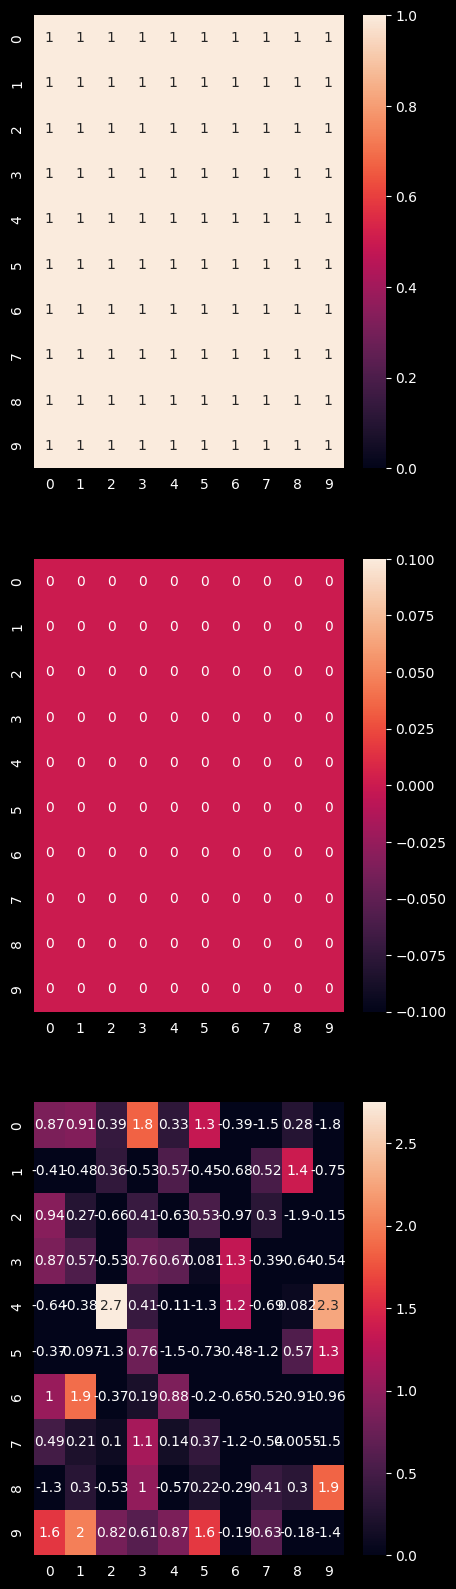

In [29]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import Axes

def show(ax:Axes, tensor) -> Axes:

    if tensor.is_cuda:
        tensor = tensor.cpu()

    try:
        sns.heatmap(tensor, annot=True, ax=ax, vmin=0)

    except:
        sns.heatmap(tensor.unsqueeze(dim=1), annot=True, ax=ax, vmin=0)


    return ax



ones = torch.ones([10,10])
zeros = torch.zeros([10,10])
rnad  = torch.randn([10,10])



fig, ax = plt.subplots(3,1, figsize=(5,20))
ax = ax.flatten()

show(ax[0], ones)
show(ax[1], zeros)
show(ax[2], rnad)

plt.show()

# Arithmetic Operations

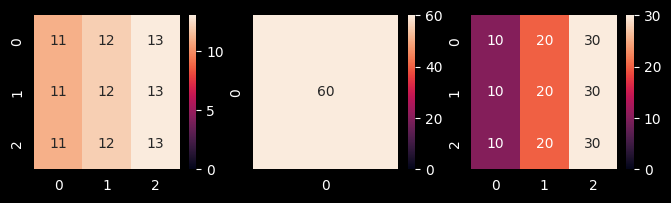

In [34]:
def operations(a,b):
    sum =  a + b
    prod = a @ b
    dot_prod = a * b

    return sum, prod, dot_prod

a = torch.Tensor([1,2,3])
b = torch.Tensor([[10], [10], [10]])

s,p,dp = operations(a,b)

fig, ax = plt.subplots(1,3, figsize=(8,2))
ax = ax.flatten()

show(ax[0], s)
show(ax[1], p)
show(ax[2], dp)

plt.show()

# To GPU

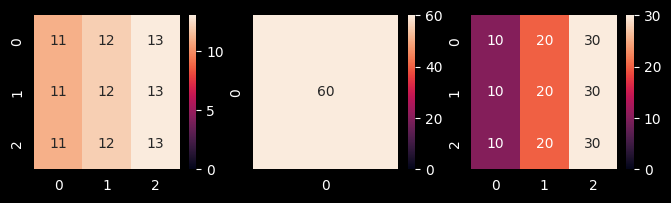

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

a = torch.Tensor([1,2,3]).to(device)
b = torch.Tensor([[10], [10], [10]]).to(device)

s,p,dp = operations(a,b)

fig, ax = plt.subplots(1,3, figsize=(8,2))
ax = ax.flatten()

show(ax[0], s)
show(ax[1], p)
show(ax[2], dp)

plt.show()

# CPU and GPU

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

a = torch.Tensor([1,2,3]).to(device)
b = torch.Tensor([[10], [10], [10]]).cpu()

s,p,dp = operations(a,b)

fig, ax = plt.subplots(1,3, figsize=(8,2))
ax = ax.flatten()

show(ax[0], s)
show(ax[1], p)
show(ax[2], dp)

plt.show()

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

# Mean

In [40]:
def calc_men_gpu(a:torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    a = a.to(device)

    mean = a.mean().item()
    std = a.std().item()

    return mean, std

a = torch.Tensor([1,2,3])

calc_men_gpu(a)

(2.0, 1.0)